# BTC Polymarket Backtest

## Strategy

Polymarket has a daily series: **"Bitcoin above $X on [date]?"**

- Settlement: Binance BTC/USDT 1-min candle **close** at **noon ET (UTC 16:00)**
- 11 strike prices per day, $2K apart (e.g. $60K, $62K, ..., $80K)
- Each strike is an independent Yes/No market

## Edge Detection

```
1. Fetch BTC hourly candles from Binance
2. Calculate hourly std (standard deviation) from last 20 candles
3. Project std to settlement: projected_std = hourly_std * sqrt(hours_remaining)
4. Calculate P(BTC >= strike) using:
   - Gaussian: norm.cdf
   - Historical: count past returns that would exceed strike
5. Compare with Polymarket Yes price
6. If model_prob - poly_price > 8% threshold -> Buy Yes
```

---
## 1. Load Backtest Results

In [11]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_csv('backtest_results.csv')
df['targetDate'] = pd.to_datetime(df['targetDate'])
df['yesWon'] = df['yesWon'].astype(bool)

print(f'Total records: {len(df)}')
print(f'Date range: {df["targetDate"].min().date()} ~ {df["targetDate"].max().date()}')
print(f'Unique days: {df["targetDate"].nunique()}')
print(f'Overall Yes win rate: {df["yesWon"].mean():.1%}')
df.head()

Total records: 1036
Date range: 2025-08-29 ~ 2026-03-17
Unique days: 171
Overall Yes win rate: 87.0%


,targetDate,signalDt,hoursAhead,targetPrice,currentPrice,hourlyStd,projectedStd,yesPrice,yesPriceSource,gaussProb,histProb,gaussEdge,histEdge,gaussKelly,histKelly,gaussEv1,histEv1,yesWon,eventVolume
0,2025-08-29,2025-08-29 09:00:00+00:00,7.0,106000.0,109772.71,954.558698,2525.524927,1.0,lastTrade,0.932390,0.997213,-0.067610,-0.002787,0.0,0.0,-0.067610,-0.002787,True,2.348068e+06
1,2025-08-29,2025-08-29 09:00:00+00:00,7.0,108000.0,109772.71,954.558698,2525.524927,1.0,lastTrade,0.758635,0.959591,-0.241365,-0.040409,0.0,0.0,-0.241365,-0.040409,True,2.348068e+06
2,2025-09-01,2025-09-01 09:00:00+00:00,7.0,104000.0,109524.12,663.823677,1756.312364,1.0,lastTrade,0.999170,1.000000,-0.000830,0.000000,0.0,0.0,-0.000830,0.000000,True,1.930582e+06
3,2025-09-01,2025-09-01 09:00:00+00:00,7.0,106000.0,109524.12,663.823677,1756.312364,1.0,lastTrade,0.977601,0.997213,-0.022399,-0.002787,0.0,0.0,-0.022399,-0.002787,True,1.930582e+06
4,2025-09-01,2025-09-01 09:00:00+00:00,7.0,108000.0,109524.12,663.823677,1756.312364,1.0,lastTrade,0.807247,0.942870,-0.192753,-0.057130,0.0,0.0,-0.192753,-0.057130,True,1.930582e+06


---
## 2. What does each row look like?

Each row = **one day x one strike**

| Column | Meaning |
|---|---|
| `targetDate` | Date of the event |
| `targetPrice` | Strike price ($58K, $60K, ...) |
| `currentPrice` | BTC price at signal time (UTC 09:00) |
| `hourlyStd` | Std from last 20 hourly candles |
| `projectedStd` | hourlyStd * sqrt(hours_remaining) |
| `yesPrice` | Polymarket Yes price at signal time |
| `gaussProb` | Gaussian model probability |
| `histProb` | Historical model probability |
| `gaussEdge` | gaussProb - yesPrice |
| `histEdge` | histProb - yesPrice |
| `yesWon` | Did Yes actually win? |

In [12]:
# Example: one day's data
sampleDate = df[df['targetDate'] == df['targetDate'].unique()[100]]
print(f'Date: {sampleDate["targetDate"].iloc[0].date()}')
print(f'BTC price at signal time: ${sampleDate["currentPrice"].iloc[0]:,.0f}')
print(f'Hourly std: ${sampleDate["hourlyStd"].iloc[0]:,.0f}')
print(f'Projected std: ${sampleDate["projectedStd"].iloc[0]:,.0f}')
print()
cols = ['targetPrice','yesPrice','gaussProb','histProb','gaussEdge','histEdge','yesWon']
sampleDate[cols].sort_values('targetPrice')

Date: 2025-12-28
BTC price at signal time: $87,800
Hourly std: $124
Projected std: $352



,targetPrice,yesPrice,gaussProb,histProb,gaussEdge,histEdge,yesWon
531,78000.0,1.0,1.0,1.000000,0.000000e+00,0.000000,True
532,80000.0,1.0,1.0,1.000000,0.000000e+00,0.000000,True
533,82000.0,1.0,1.0,0.999535,0.000000e+00,-0.000465,True
534,84000.0,1.0,1.0,0.988848,0.000000e+00,-0.011152,True
535,86000.0,1.0,1.0,0.914963,-1.540477e-07,-0.085037,True


---
## 3. Filter: Only Buy Yes signals

Rules:
- **Only buy Yes** (not No — backtest showed No direction loses money)
- Edge threshold: **8%** (histEdge > 0.08)
- Bet size: **$1 per signal**

Three strategies:
1. **Gaussian**: gaussEdge > 8%
2. **Historical**: histEdge > 8%
3. **Gauss+Hist**: both > 8%

In [13]:
THRESHOLD = 0.08
BET = 1.0

gaussSignals = df[df['gaussEdge'] > THRESHOLD].copy()
histSignals  = df[df['histEdge']  > THRESHOLD].copy()
bothSignals  = df[(df['gaussEdge'] > THRESHOLD) & (df['histEdge'] > THRESHOLD)].copy()

print(f'Gaussian signals:  {len(gaussSignals):>3}  Win rate: {gaussSignals["yesWon"].mean():.1%}')
print(f'Historical signals:{len(histSignals):>3}  Win rate: {histSignals["yesWon"].mean():.1%}')
print(f'Both signals:      {len(bothSignals):>3}  Win rate: {bothSignals["yesWon"].mean():.1%}')

Gaussian signals:   23  Win rate: 34.8%
Historical signals: 15  Win rate: 66.7%
Both signals:        8  Win rate: 50.0%


---
## 4. Every trade (Historical method)

Each row = one trade we would have placed

In [14]:
def buildTradeLog(signals):
    """Build a trade log with PnL for each signal"""
    trades = signals.sort_values('targetDate').copy()
    trades['pnl'] = trades.apply(
        lambda r: (BET / r['yesPrice'] - BET) if r['yesWon'] else -BET, axis=1
    )
    trades['cumPnl'] = trades['pnl'].cumsum()
    return trades

histTrades = buildTradeLog(histSignals)

# Display all trades
display_cols = [
    'targetDate', 'targetPrice', 'currentPrice',
    'yesPrice', 'histProb', 'histEdge',
    'yesWon', 'pnl', 'cumPnl'
]

print(f'=== Historical Method: All {len(histTrades)} trades ===')
print()

styled = histTrades[display_cols].copy()
styled['targetDate'] = styled['targetDate'].dt.strftime('%Y-%m-%d')
styled.columns = ['Date', 'Strike', 'BTC Price', 'Poly Yes', 'Model %', 'Edge', 'Won?', 'PnL', 'Cum PnL']
styled

=== Historical Method: All 15 trades ===



,Date,Strike,BTC Price,Poly Yes,Model %,Edge,Won?,PnL,Cum PnL
777,2026-02-20,68000.0,68218.85,0.4300,0.650093,0.220093,False,-1.000000,-1.000000
787,2026-02-21,68000.0,68147.53,0.3600,0.606877,0.246877,True,1.777778,0.777778
809,2026-02-23,66000.0,66404.91,0.4750,0.739777,0.264777,False,-1.000000,-0.222222
818,2026-02-24,62000.0,63249.99,0.7965,0.918680,0.122180,True,0.255493,0.033271
830,2026-02-25,64000.0,65558.71,0.8050,0.937268,0.132268,True,0.242236,0.275507
844,2026-02-26,68000.0,68589.41,0.4550,0.784387,0.329387,False,-1.000000,-0.724493
862,2026-02-28,62000.0,63658.54,0.8555,0.943309,0.087809,True,0.168907,-0.555586
898,2026-03-04,68000.0,71520.76,0.8250,0.993497,0.168497,True,0.212121,-0.343465
899,2026-03-04,70000.0,71520.76,0.3800,0.928007,0.548007,True,1.631579,1.288114
900,2026-03-04,72000.0,71520.76,0.0740,0.216907,0.142907,True,12.513514,13.801627


---
## 5. Every trade (Gaussian method)

In [15]:
gaussTrades = buildTradeLog(gaussSignals)

display_cols = [
    'targetDate', 'targetPrice', 'currentPrice',
    'yesPrice', 'gaussProb', 'gaussEdge',
    'yesWon', 'pnl', 'cumPnl'
]

print(f'=== Gaussian Method: All {len(gaussTrades)} trades ===')
print()

styled = gaussTrades[display_cols].copy()
styled['targetDate'] = styled['targetDate'].dt.strftime('%Y-%m-%d')
styled.columns = ['Date', 'Strike', 'BTC Price', 'Poly Yes', 'Model %', 'Edge', 'Won?', 'PnL', 'Cum PnL']
styled

=== Gaussian Method: All 23 trades ===



,Date,Strike,BTC Price,Poly Yes,Model %,Edge,Won?,PnL,Cum PnL
777,2026-02-20,68000.0,68218.85,0.4300,0.556157,0.126157,False,-1.000000,-1.000000
778,2026-02-20,70000.0,68218.85,0.0365,0.125184,0.088684,False,-1.000000,-2.000000
787,2026-02-21,68000.0,68147.53,0.3600,0.587645,0.227645,True,1.777778,-0.222222
810,2026-02-23,68000.0,66404.91,0.0690,0.318001,0.249001,False,-1.000000,-1.222222
811,2026-02-23,70000.0,66404.91,0.0045,0.143046,0.138546,False,-1.000000,-2.222222
819,2026-02-24,64000.0,63249.99,0.2850,0.379788,0.094788,True,2.508772,0.286550
820,2026-02-24,66000.0,63249.99,0.0285,0.130903,0.102403,False,-1.000000,-0.713450
831,2026-02-25,66000.0,65558.71,0.1800,0.413092,0.233092,True,4.555556,3.842105
832,2026-02-25,68000.0,65558.71,0.0190,0.112210,0.093210,True,51.631579,55.473684
844,2026-02-26,68000.0,68589.41,0.4550,0.644317,0.189317,False,-1.000000,54.473684


---
## 6. Every trade (Gauss + Historical)

In [16]:
bothTrades = buildTradeLog(bothSignals)

display_cols = [
    'targetDate', 'targetPrice', 'currentPrice',
    'yesPrice', 'gaussProb', 'histProb', 'gaussEdge', 'histEdge',
    'yesWon', 'pnl', 'cumPnl'
]

print(f'=== Gauss+Hist Method: All {len(bothTrades)} trades ===')
print()

styled = bothTrades[display_cols].copy()
styled['targetDate'] = styled['targetDate'].dt.strftime('%Y-%m-%d')
styled.columns = ['Date', 'Strike', 'BTC Price', 'Poly Yes', 'Gauss %', 'Hist %', 'G Edge', 'H Edge', 'Won?', 'PnL', 'Cum PnL']
styled

=== Gauss+Hist Method: All 8 trades ===



,Date,Strike,BTC Price,Poly Yes,Gauss %,Hist %,G Edge,H Edge,Won?,PnL,Cum PnL
777,2026-02-20,68000.0,68218.85,0.430,0.556157,0.650093,0.126157,0.220093,False,-1.000000,-1.000000
787,2026-02-21,68000.0,68147.53,0.360,0.587645,0.606877,0.227645,0.246877,True,1.777778,0.777778
844,2026-02-26,68000.0,68589.41,0.455,0.644317,0.784387,0.189317,0.329387,False,-1.000000,-0.222222
899,2026-03-04,70000.0,71520.76,0.380,0.700780,0.928007,0.320780,0.548007,True,1.631579,1.409357
900,2026-03-04,72000.0,71520.76,0.074,0.434093,0.216907,0.360093,0.142907,True,12.513514,13.922870
911,2026-03-05,70000.0,72591.59,0.885,0.969129,0.980028,0.084129,0.095028,True,0.129944,14.052814
912,2026-03-05,72000.0,72591.59,0.510,0.665108,0.787738,0.155108,0.277738,False,-1.000000,13.052814
999,2026-03-13,72000.0,72006.57,0.395,0.501338,0.494194,0.106338,0.099194,False,-1.000000,12.052814


---
## 7. Performance Chart

Cumulative PnL for all three strategies, starting from $10 capital, $1 per bet

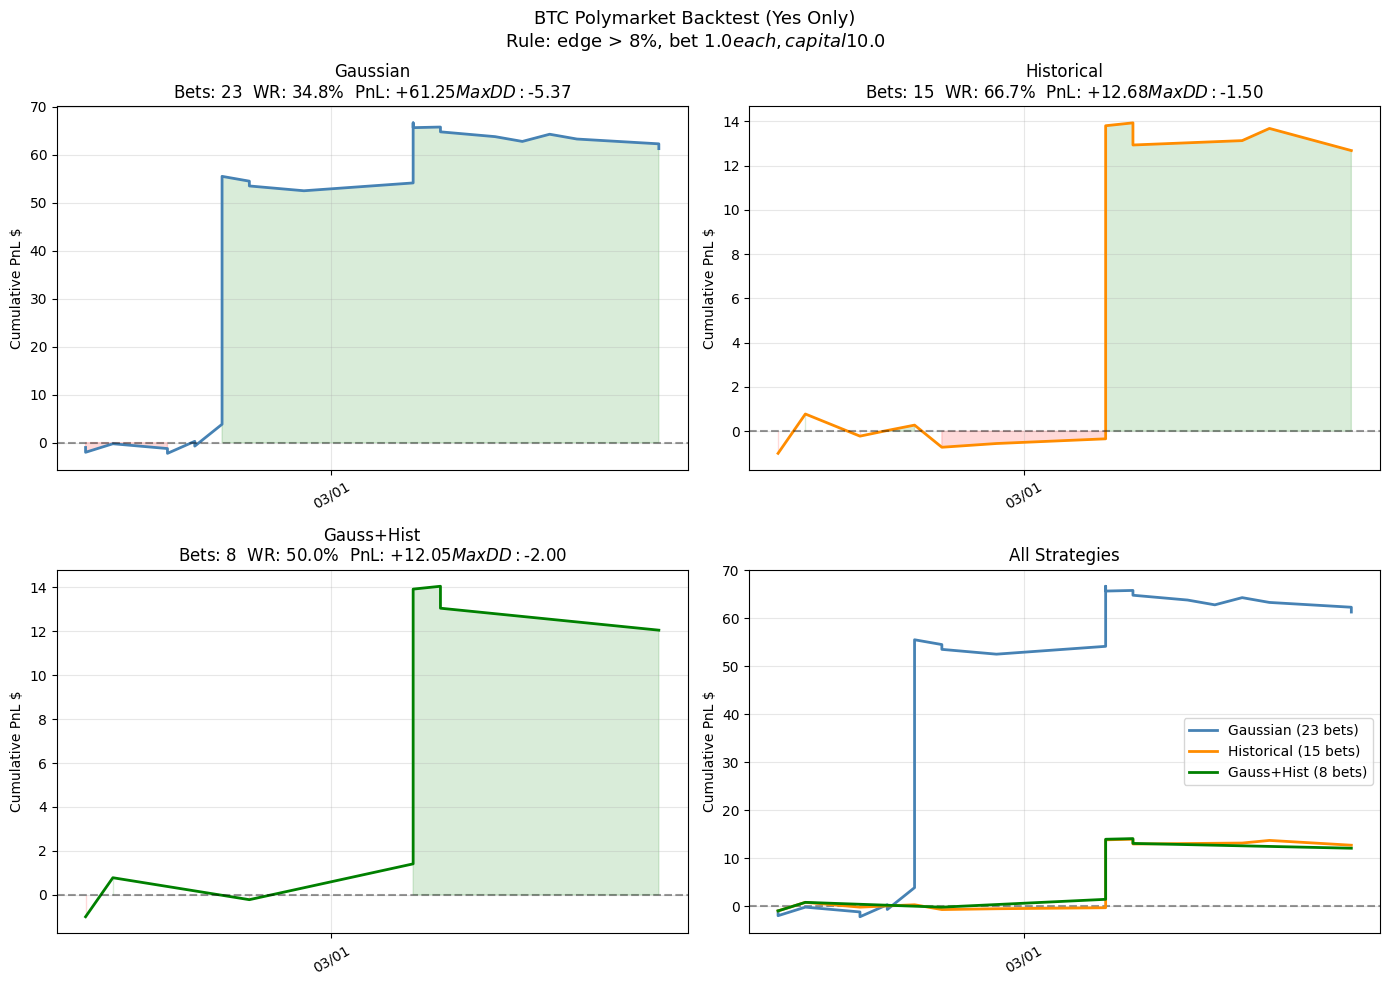

In [17]:
INITIAL = 10.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'BTC Polymarket Backtest (Yes Only)\n'
    f'Rule: edge > {THRESHOLD*100:.0f}%, bet ${BET} each, capital ${INITIAL}',
    fontsize=13
)

strategies = [
    ('Gaussian',  gaussTrades, 'steelblue'),
    ('Historical', histTrades, 'darkorange'),
    ('Gauss+Hist', bothTrades, 'green'),
]

for i, (name, trades, color) in enumerate(strategies):
    ax = axes[0][i] if i < 2 else axes[1][0]
    if trades.empty:
        ax.text(0.5, 0.5, 'No signal', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name)
        continue

    wins = trades['yesWon'].sum()
    total = len(trades)
    finalPnl = trades['cumPnl'].iloc[-1]
    maxDD = (trades['cumPnl'] - trades['cumPnl'].cummax()).min()

    ax.plot(trades['targetDate'], trades['cumPnl'], color=color, linewidth=2)
    ax.fill_between(trades['targetDate'], trades['cumPnl'], 0,
                    where=trades['cumPnl'] >= 0, alpha=0.15, color='green')
    ax.fill_between(trades['targetDate'], trades['cumPnl'], 0,
                    where=trades['cumPnl'] < 0, alpha=0.15, color='red')
    ax.axhline(0, color='black', linestyle='--', alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    ax.set_title(f'{name}\nBets: {total}  WR: {wins/total:.1%}  PnL: ${finalPnl:+.2f}  MaxDD: ${maxDD:.2f}')
    ax.set_ylabel('Cumulative PnL $')

# Bottom right: all strategies
ax = axes[1][1]
ax.axhline(0, color='black', linestyle='--', alpha=0.4)
for name, trades, color in strategies:
    if not trades.empty:
        ax.plot(trades['targetDate'], trades['cumPnl'], color=color,
                linewidth=2, label=f'{name} ({len(trades)} bets)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.set_title('All Strategies')
ax.set_ylabel('Cumulative PnL $')
ax.legend()

plt.tight_layout()
plt.show()

---
## 8. Summary Table

In [18]:
print(f'Threshold: {THRESHOLD*100:.0f}%  |  Bet: ${BET}  |  Capital: ${INITIAL}')
print(f'{"":-<55}')
print(f'{"Strategy":<14} {"Bets":>5} {"Wins":>5} {"WR":>7} {"PnL":>10} {"MaxDD":>10}')
print(f'{"":-<55}')

for name, trades in [('Gaussian', gaussTrades), ('Historical', histTrades), ('Gauss+Hist', bothTrades)]:
    if trades.empty:
        print(f'{name:<14} {"No signal":>5}')
        continue
    wins = trades['yesWon'].sum()
    total = len(trades)
    finalPnl = trades['cumPnl'].iloc[-1]
    maxDD = (trades['cumPnl'] - trades['cumPnl'].cummax()).min()
    print(f'{name:<14} {total:>5} {wins:>5} {wins/total:>6.1%} {finalPnl:>+9.2f} {maxDD:>+9.2f}')

Threshold: 8%  |  Bet: $1.0  |  Capital: $10.0
-------------------------------------------------------
Strategy        Bets  Wins      WR        PnL      MaxDD
-------------------------------------------------------
Gaussian          23     8  34.8%    +61.25     -5.37
Historical        15    10  66.7%    +12.68     -1.50
Gauss+Hist         8     4  50.0%    +12.05     -2.00


---
## 9. Calibration Curve

When the model says X%, how often does Yes actually win?

- Points on diagonal = well calibrated
- Points above diagonal = model underestimates (edge exists)
- Points below diagonal = model overestimates

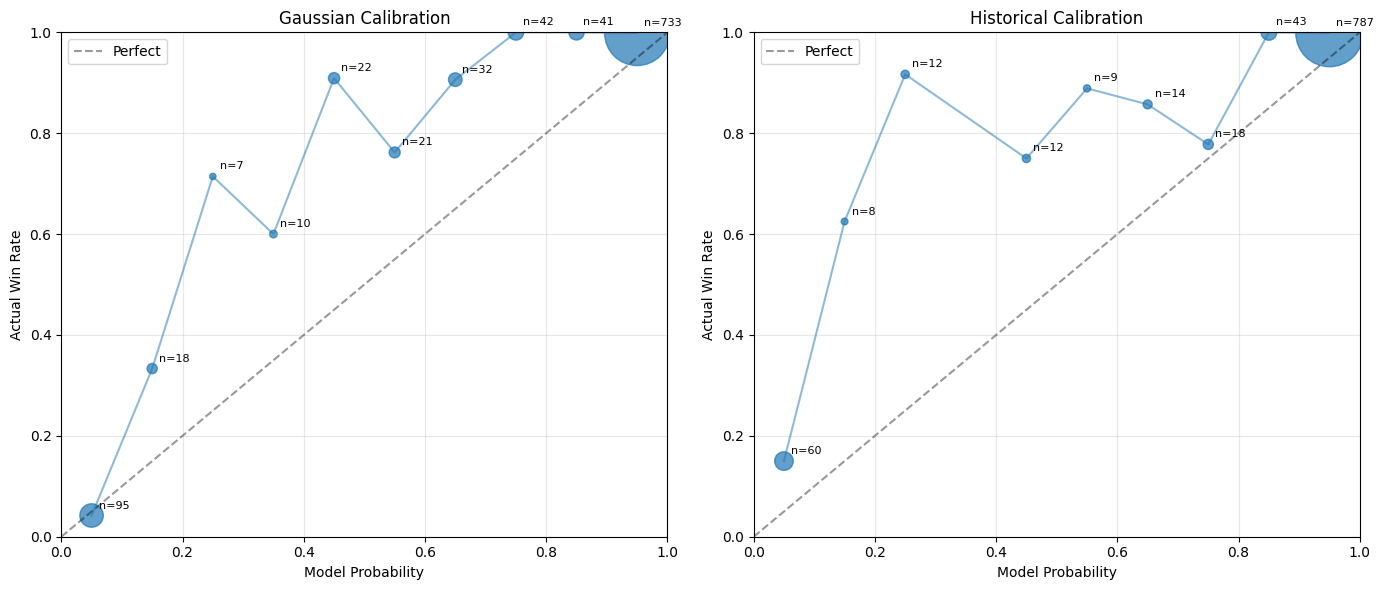

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0-10%','10-20%','20-30%','30-40%','40-50%','50-60%','60-70%','70-80%','80-90%','90-100%']

for ax, col, title in [
    (axes[0], 'gaussProb', 'Gaussian Calibration'),
    (axes[1], 'histProb',  'Historical Calibration'),
]:
    tmp = df.copy()
    tmp['_bin'] = pd.cut(tmp[col], bins=bins, labels=labels)
    grouped = tmp.groupby('_bin', observed=True).agg(
        actual=('yesWon', 'mean'),
        count=('yesWon', 'count')
    ).reset_index()
    grouped = grouped[grouped['count'] >= 5]
    midpoints = [float(l.replace('%','').split('-')[0])/100 + 0.05 for l in grouped['_bin']]

    ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Perfect')
    ax.scatter(midpoints, grouped['actual'], s=grouped['count']*3, alpha=0.7)
    ax.plot(midpoints, grouped['actual'], alpha=0.5)
    for x, y, n in zip(midpoints, grouped['actual'], grouped['count']):
        ax.annotate(f'n={n}', (x, y), textcoords='offset points', xytext=(5,5), fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Model Probability')
    ax.set_ylabel('Actual Win Rate')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

---
## 10. Edge Distribution

Histogram of (model_prob - poly_price) for all records

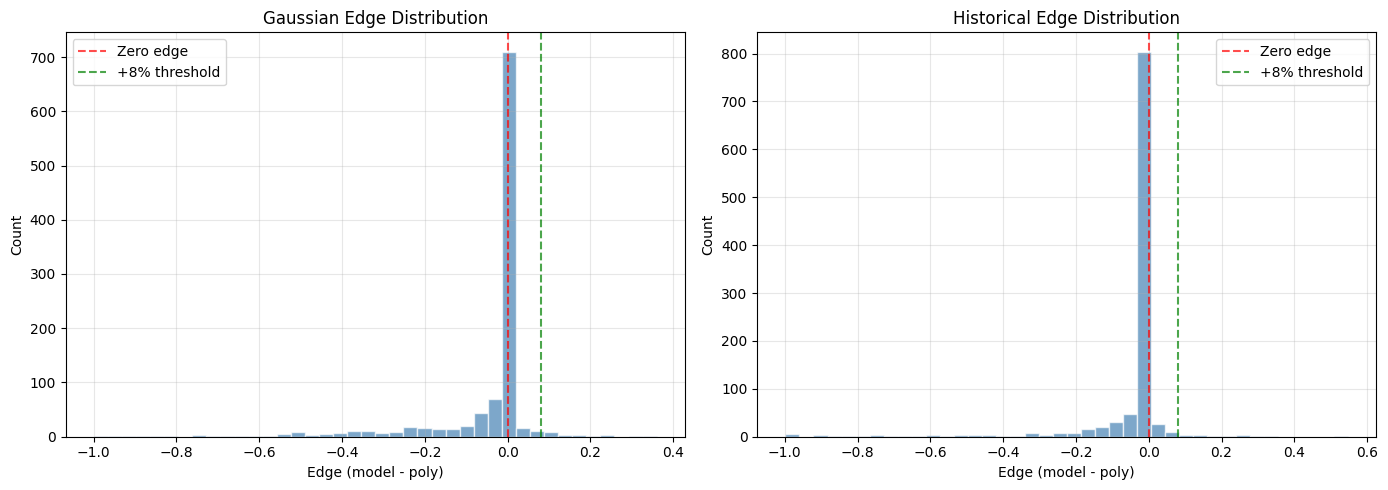

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'gaussEdge', 'Gaussian Edge Distribution'),
    (axes[1], 'histEdge',  'Historical Edge Distribution'),
]:
    ax.hist(df[col], bins=40, edgecolor='white', alpha=0.7, color='steelblue')
    ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero edge')
    ax.axvline(THRESHOLD, color='green', linestyle='--', alpha=0.7, label=f'+{THRESHOLD*100:.0f}% threshold')
    ax.set_xlabel('Edge (model - poly)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()